# PISO algorithm implementation


## Modelo 

Solves the incompressible viscous Navier-Stokes equations.

Momentum Eq.: $\frac{\partial u}{\partial t} + (u.\nabla)u = -\frac{\nabla p}{\rho} + \nu \nabla^2u + f$

Incompressibility Eq.: $\nabla u = 0$


## Case: Lid Driven cavity

Equivalent to lid driven cavity case in openFoam.



## Algorithm

Implementation of the PISO algoritm, identical to the icoFoam solver from  openFoam minus the orthogonality correction. 

$$\bold{M}.u^{n} = u^{n-1}/\Delta t -\nabla p = \bold{S} \qquad (1) $$

$$\bold{H} = \bold{A}.u^{n} - \bold{S} \qquad (2)$$

$$\nabla^2p = \bold{A}\nabla . (\bold{A}^{-1}\bold{H}) \qquad (3)$$

$$u^{n} = \bold{A}^{-1}\bold{H} - \bold{A}^{-1}\nabla p \qquad (4)$$

The PISO algorithm consists of an interation of the steps 1 -> 2 -> 3 -> 4 -> 2 -> ... apllied for both u and v components of the velocity, wich are solved independently, for each time step until convergence, then proceding to the next step.



# Code:

### Imports

In [38]:
import numpy as np
from matplotlib import pyplot as plt
import gmsh
import scipy.sparse as sp
import scipy.sparse.linalg as spla


### Constants

In [63]:
N_CELLS_X = 100
N_CELLS_Y = 100
RUN_TIME = 1
KINEMATIC_VISCOSITY = 0.1
N_ITER_STEP = 150
TOLERANCE_ITER = 10**(-3)
DENSITY = 1.0
HORIZONTAL_VELOCITY_TOP = 1.0
CFL = 1

#Under-relaxation factors
ALPHA_P = 0.8
ALPHA_U = 0.8
ALPHA_V = 0.8

### Domain Definition

In [64]:
dx = 1/N_CELLS_X
dy = 1/N_CELLS_Y
dt = np.min([dx, dy]) * CFL / (HORIZONTAL_VELOCITY_TOP)
print(f"dt:{dt}")


class Face():
    def __init__(self, node_coords, owner_cell, neighbour_cell, boundary_name=None):
        self.nodes: np.ndarray = node_coords          # (2,2) endpoint coords of the edge
        self.owner_cell: "Cell" = owner_cell
        self.neighbour_cell: "Cell|None" = neighbour_cell   # None for boundary faces
        self.boundary_name: str|None = boundary_name

        self.face_center = node_coords.mean(axis=0)
        edge = node_coords[1] - node_coords[0]
        self.face_area = np.linalg.norm(edge)          # edge length (2D "area", unit depth)
        normal = np.array([edge[1], -edge[0]])
        normal /= np.linalg.norm(normal)
        # Orient outward from the owner cell
        if np.dot(normal, self.face_center - owner_cell.center) < 0:
            normal = -normal
        self.face_normal = normal

        if self.neighbour_cell is not None:
            d_own = np.dot(self.face_normal, self.face_center - self.owner_cell.center)
            d_nei = np.dot(self.face_normal, self.neighbour_cell.center - self.owner_cell.center)
            self.weight = d_own / d_nei
        else:
            self.weight = 1.0   # boundary face: value taken from owner cell + BC

    def flux_in_face(self):
        if self.neighbour_cell is not None:
            return (1 - self.weight) * self.owner_cell.value + self.weight * self.neighbour_cell.value
        return self.owner_cell.value


class Cell():
    def __init__(self, cell_id, node_coords, value=0.0):
        self.id = cell_id
        self.node_coords = node_coords      # (4,2) corner coordinates, ccw order
        self.center = node_coords.mean(axis=0)
        x, y = node_coords[:, 0], node_coords[:, 1]
        self.volume = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))  # shoelace
        self.faces: list[Face] = []
        self.value = value


class Mesh():
    def __init__(self):
        self.cells: list[Cell] = []
        self.faces: list[Face] = []

    def generate2DQuadrilateralMeshGMSH(self, lx=1.0, ly=1.0, nx=30, ny=20):
        """Builds a structured quad mesh of a rectangle with GMSH (transfinite + recombine)
           and converts it into this Mesh's Cell/Face representation. The four sides are
           tagged as physical groups "bottom", "right", "top", "left" so boundary faces
           carry which wall they belong to."""
        # Initialize mesh
        gmsh.initialize()
        # initialize model
        gmsh.model.add("cavity")

        # Add geometric points
        p1 = gmsh.model.geo.addPoint(0, 0, 0)
        p2 = gmsh.model.geo.addPoint(lx, 0, 0)
        p3 = gmsh.model.geo.addPoint(lx, ly, 0)
        p4 = gmsh.model.geo.addPoint(0, ly, 0)

        # Add lines 
        l_bottom = gmsh.model.geo.addLine(p1, p2)
        l_right = gmsh.model.geo.addLine(p2, p3)
        l_top = gmsh.model.geo.addLine(p3, p4)
        l_left = gmsh.model.geo.addLine(p4, p1)

        # Create loop to bound surface
        loop = gmsh.model.geo.addCurveLoop([l_bottom, l_right, l_top, l_left])
        # Defines surface from created loop
        surface = gmsh.model.geo.addPlaneSurface([loop])

        # Transform lines in transfinite curves
        gmsh.model.geo.mesh.setTransfiniteCurve(l_bottom, nx + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_top, nx + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_left, ny + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_right, ny + 1)
        # Create surface mesh
        gmsh.model.geo.mesh.setTransfiniteSurface(surface)
        # Recombine triangle mesh to quad mesh
        gmsh.model.geo.mesh.setRecombine(2, surface)

        # Add physical groups to the models for boundary conditions
        gmsh.model.geo.synchronize()
        gmsh.model.addPhysicalGroup(1, [l_bottom], name="bottom")
        gmsh.model.addPhysicalGroup(1, [l_right], name="right")
        gmsh.model.addPhysicalGroup(1, [l_top], name="top")
        gmsh.model.addPhysicalGroup(1, [l_left], name="left")

        # Generates 2D mesh
        gmsh.model.mesh.generate(2)

        # Get mesh nodes
        node_tags, node_coords_flat, _ = gmsh.model.mesh.getNodes()
        # Create dict for nodes
        coords = {tag: np.array(node_coords_flat[3*i:3*i+2])
                  for i, tag in enumerate(node_tags)}

        # Get quad elements
        _, quad_nodes = gmsh.model.mesh.getElementsByType(3)  # Type 3 -> 4-node quadrangle
        # Reshapes the array into lenght 4 arrays
        quad_nodes = quad_nodes.reshape(-1, 4)

        # Get the boundary elements
        boundary_edges = {}
        for name in ("bottom", "right", "top", "left"):
            for dim, tag in gmsh.model.getEntitiesForPhysicalName(name):
                _, edge_nodes = gmsh.model.mesh.getElementsByType(1, tag)  # Type 1 -> 2-node line
                for a, b in edge_nodes.reshape(-1, 2):
                    boundary_edges[frozenset((a, b))] = name

        # End mesh generation
        gmsh.finalize()

        # Create cell form quad nodes
        self.cells = [Cell(i, np.array([coords[t] for t in quad]))
                      for i, quad in enumerate(quad_nodes)]

        # Relates edge to the cells it belongs
        edge_owners: dict = {}
        for cell, quad in zip(self.cells, quad_nodes):
            for k in range(4):
                a, b = quad[k], quad[(k + 1) % 4]
                edge_owners.setdefault(frozenset((a, b)), []).append((cell, a, b))

        # Create faces fromn edge
        for edge_key, owners in edge_owners.items():
            cell, a, b = owners[0]
            node_pair = np.array([coords[a], coords[b]])
            if len(owners) == 2:
                neighbour = owners[1][0]
                face = Face(node_pair, cell, neighbour)
                neighbour.faces.append(face)
            else:
                face = Face(node_pair, cell, None, boundary_name=boundary_edges.get(edge_key))
            cell.faces.append(face)
            self.faces.append(face)

mesh = Mesh()
mesh.generate2DQuadrilateralMeshGMSH(lx=1.0, ly=1.0, nx=N_CELLS_X, ny=N_CELLS_Y)
print(f"Cells: {len(mesh.cells)}, Faces: {len(mesh.faces)}")
print(f"Total Volume: {sum([cell.volume for cell in mesh.cells])}")
print(f"Total Area: {sum([face.face_area for face in mesh.faces])}")


dt:0.01
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000276929s, CPU 0.000426s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.00139034s, CPU 0.001402s)
Info    : 10201 nodes 10404 elements
Cells: 10000, Faces: 20200
Total Volume: 1.000000000000011
Total Area: 201.99999999999451


### Mometum Equation Discretization

The obejctive is to turn the Navier-Stoke equation into matrix form to solve numerically. 

$$\frac{\partial u}{\partial t} + (u.\nabla)u = -\frac{\nabla p}{\rho} + \nu \nabla^2u + f \implies \bold{M}.u = \bold{S}$$


#### Discretization

The approach used here is the Finite Volumes Method.

This implementation is based on the [Notes on Computations Fluid Dynamcs](https://doc.cfd.direct/notes/cfd-general-principles/overview-of-discretisation)

##### Time derivative:

The time derivative (${\partial u}/{\partial t}$) is discretized by a simple euler scheme, with the previous time step being known from the initial condition or the last iteration, contributing to the source term.

$${\partial u}/{\partial t} \approx \frac{u^{n}_{i,j} - u^{n-1}_{i,j}}{\Delta t}$$


##### Difussion term:

The difusion ($\nu \nabla^2u$) term can be discretized  with traditional finite diference scheme.

$$ \nabla^2u \approx \frac{1}{V}\sum |S_f| \nabla_n u_f$$

Where $V$ and $S_f$ are the volume and face area of the cell and $\nabla_n u_f$ is the gradient normal to the face.

The gradient term ($\nabla_n u_f$) in the equation can be discretized as:

$$ \nabla_n u_f = \frac{u_n - u_p}{|\Delta d|} $$

For non orthogonal meshes the equations has to be corrected to:

$$ \nabla_n u_f = \frac{u_n - u_p}{|\Delta d| \cos(\theta)} + \left(\bold{n} - \frac{\Delta d}{|\Delta d|\cos(\theta)}\right).(\Delta u)_f $$

This helps with accuracy and convergence up to the $\theta \lesssim 75\degree$.


##### Advective term:

The advective term models the transport of a given quantity ($\Psi$) by the motion ($u$) of the fluid. 

$$ \nabla\,(u.\Psi) = \frac{1}{V}\sum_f \phi_f . \Psi_f; \text{  with } \phi_f = S_f . u_f$$

The value $u_f$ is generally determined by the linear interpolation of the values ate the cell centers.

To evaluate $\Psi_f$ a series of discretization schemes are available. The selection of either of those options are a trade-off between accuracy and boundedness.

1. Linear Interpolation:   $\Psi_f = \alpha \Psi_{\text{up}} + (1 - \alpha) \Psi_{\text{down}}$
    - Unbounded and unstable solutions;
1. Upwind Scheme:     $\Psi_f = \Psi_{\text{up}}$
    - Guarantee boundedness;
    - Highly difussive;  
1. Limited Advection Scheme:    $\Psi_f = \beta(r) \Psi_{\text{up}} + (1 - \beta(r)) \Psi_{\text{down}}$
    - Adress the boudedness and accuracy with limiter function $\beta(r)$;

        $$ r = \max \left[ 2\frac{ \nabla_n \Psi_f . \Delta d . \nabla \Psi}{|\Delta d |  \nabla_n \Psi_f . \nabla_n \Psi_f} -1, 0\right] $$

    - These schemes fall under the Total Variation Diminishing schemes;
    - Limited Linear: 

        $\beta(r) = \min (2r, 1)$

        - Robust;
        - Low Diffusion;
        - Not symmetric;
    - Minmod: 
    
        $\beta(r) = \min (r, 1)$

        - No downwind interpolation;
        - More Diffusive;
        - Symmetric;
    - van Leer:

        $\beta(r) = \frac{r + |r|}{1+ |r|}$

        - Some downwind interpolation;
        - Low diffusion;
        - No jump in function values;
        - Symmetric;
    - van Albada:

        $\beta(r) = \frac{r + r²}{1+r²}$

        - Less downwind interpolation than van Leer;
        - Low diffusion;
        - No jump in function values;
        - Symmetric;
    
    - Linear Upwind w. Gradient Limiting:

        $\beta(r) = \min (2r, (r+1)/2, 2) $

        - Lots of downwind interpolation;
        - Strongly bounded; 
        - Good accuracy;

For vector quantities the limiter is calculated to be based on the worst case component.


In [43]:
def LimitedLinear(r):
    return min(2*r,1)

def Minmod(r):
    return min(r,1)

def vanLeer(r):
    return (r + abs(r))/(1 + abs(r))

def vanAlbada(r):
    return (r + r**2)/(1 + r**2)

def LinearUpwind(r):
    return min( 2*r, 0.5 * (r + 1), 2)

### Matrix assembly

For each component u and v of the velocity the above discretizations are used to assemble the NS equation in matrix form.

In [52]:
def DiffusionMatrix(mesh, nu, boundary_values):
    """FV diffusion operator  -nu * div(grad u)  with Dirichlet BCs.

       Interior face f (owner P, neighbour N):  a_f = nu*|S_f| / |d_PN|
           M[P,P]+=a_f, M[P,N]-=a_f,  M[N,N]+=a_f, M[N,P]-=a_f
       Boundary face, Dirichlet value u_b:      a_f = nu*|S_f| / |d_Pf|
           M[P,P]+=a_f,  b[P]+=a_f*u_b
    """
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    b = np.zeros(n)
    for f in mesh.faces:
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            d = np.linalg.norm(f.neighbour_cell.center - f.owner_cell.center)
            a = nu * f.face_area / d
            rows += [P, P, N, N]
            cols += [P, N, N, P]
            vals += [a, -a, a, -a]
        else:
            d = np.linalg.norm(f.face_center - f.owner_cell.center)
            a = nu * f.face_area / d
            rows.append(P); cols.append(P); vals.append(a)
            b[P] += a * boundary_values[f.boundary_name]
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return M, b
 

def DdtMatrix(mesh, dt, u_prev):     # u_prev: flat array indexed by cell.id
    n = len(mesh.cells)
    vols = np.array([c.volume for c in mesh.cells]) / dt
    M = sp.diags(vols).tocsr()
    b = vols * u_prev
    return M, b


def FaceFluxes(mesh, u, v, bv_u, bv_v):
    """Volumetric face flux  phi_f = S_f . u_f  for every face, owner-outward oriented.
       
       u, v: cell-centred arrays indexed by cell.id;  bv_*: {wall: value} for boundaries.
       
       Interior face velocity is linearly interpolated with the face weight g.
    """
    phi = np.empty(len(mesh.faces))
    for k, f in enumerate(mesh.faces):
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            g = f.weight                       # neighbour weight (fraction toward N)
            uf = (1 - g) * u[P] + g * u[N]
            vf = (1 - g) * v[P] + g * v[N]
        else:
            uf = bv_u[f.boundary_name]
            vf = bv_v[f.boundary_name]
        phi[k] = f.face_area * (f.face_normal[0] * uf + f.face_normal[1] * vf)
    return phi


def ConvectionMatrix(mesh, phi, boundary_values):
    """FV advection operator  div(phi * Psi)  integrated over each cell, upwind scheme.

       Interior face f (owner P, neighbour N), flux phi_f:
           M[P,P]+=max(phi,0), M[P,N]+=min(phi,0)
           M[N,N]+=max(-phi,0), M[N,P]+=min(-phi,0)
       Boundary face:  outflow (phi>=0) -> M[P,P]+=phi   (upwind = owner)
                       inflow  (phi<0)  -> b[P]-=phi*Psi_b (known boundary value)
       Returns (M, b) with the term equal to  M @ Psi - b.
    """
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    b = np.zeros(n)
    for k, f in enumerate(mesh.faces):
        P = f.owner_cell.id
        ph = phi[k]
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            rows += [P, P, N, N]
            cols += [P, N, N, P]
            vals += [max(ph, 0.0), min(ph, 0.0), max(-ph, 0.0), min(-ph, 0.0)]
        elif ph >= 0.0:                        # outflow: Psi_f = Psi_P
            rows.append(P); cols.append(P); vals.append(ph)
        else:                                  # inflow: Psi_f = Psi_b (known)
            b[P] -= ph * boundary_values[f.boundary_name]
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return M, b


def CellGradient(mesh, field, boundary_values=None):
    """Green-Gauss cell-centred gradient:  grad(phi)_P = (1/V_P) sum_f phi_f * S_f,
       with S_f the outward (owner) face-area vector. Returns an (n_cells, 2) array.

       field: cell-centred array indexed by cell.id.
       boundary_values: {wall: value} for Dirichlet boundary faces; if None or the wall
           is absent, the boundary face uses zero-gradient (phi_f = phi_owner). For the
           PISO pressure gradient (Neumann walls) leave it None.
    """
    n = len(mesh.cells)
    grad = np.zeros((n, 2))
    for f in mesh.faces:
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            g = f.weight
            phif = (1 - g) * field[P] + g * field[N]
        elif boundary_values is not None and f.boundary_name in boundary_values:
            phif = boundary_values[f.boundary_name]
        else:
            phif = field[P]                       # zero-gradient extrapolation
        Sf = f.face_area * f.face_normal          # outward from owner
        grad[P] += phif * Sf
        if f.neighbour_cell is not None:
            grad[N] -= phif * Sf                  # neighbour sees -S_f
    vols = np.array([c.volume for c in mesh.cells])
    return grad / vols[:, None]


In [53]:
# --- PISO-specific operators -------------------------------------------------
# The pressure step needs (a) the divergence of a face-flux field and (b) a
# variable-coefficient Laplacian: the corrected face flux is
#     phi^n_f = phiHbyA_f - (rAU/rho)_f |S_f|/d (p_N - p_P),
# so requiring sum_f phi^n_f = 0 gives  laplacian((rAU/rho), p) = div(phiHbyA).
# Using the rAU = V/A coefficient (instead of a constant one) is what makes the
# corrected flux actually divergence-free / avoids checkerboarding.

def Divergence(mesh, phi):
    """Integrated divergence per cell from a face-flux array:  sum_f phi_f (owner-outward)."""
    div = np.zeros(len(mesh.cells))
    for k, f in enumerate(mesh.faces):
        div[f.owner_cell.id] += phi[k]
        if f.neighbour_cell is not None:
            div[f.neighbour_cell.id] -= phi[k]
    return div


def PressureMatrixVar(mesh, coeff, ref_cell=0):
    """Variable-coefficient pressure Laplacian for PISO (Eq. 3), Neumann walls + pinned ref.
       Assembles  sum_f c_f |S_f|/d (p_P - p_N)  with c_f the face-interpolated coeff
       (here coeff = rAU/rho per cell). Returns (M, ref_cell); caller sets rhs[ref]=0.
    """
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    for f in mesh.faces:
        if f.neighbour_cell is None:
            continue                              # Neumann wall: no contribution
        P = f.owner_cell.id
        N = f.neighbour_cell.id
        g = f.weight
        cf = (1 - g) * coeff[P] + g * coeff[N]
        d = np.linalg.norm(f.neighbour_cell.center - f.owner_cell.center)
        a = cf * f.face_area / d
        rows += [P, P, N, N]
        cols += [P, N, N, P]
        vals += [a, -a, a, -a]
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tolil()
    M[ref_cell, :] = 0.0
    M[ref_cell, ref_cell] = 1.0                   # pin: p[ref] = 0
    return M.tocsr(), ref_cell


### Algortihm execution


In [65]:
# ---- Boundary conditions (lid-driven cavity) & initial fields ----
n = len(mesh.cells)
walls = ("bottom", "top", "left", "right")
bv_u = {"top": HORIZONTAL_VELOCITY_TOP, "bottom": 0.0, "left": 0.0, "right": 0.0}  # moving lid + no-slip
bv_v = {w: 0.0 for w in walls}                                                     # no penetration
vols = np.array([c.volume for c in mesh.cells])

# Cell-centred fields, flat arrays indexed by cell.id
u = np.zeros(n)
v = np.zeros(n)
p = np.zeros(n)

t = 0.0
# ---- Outer time loop ----
while t < RUN_TIME:
    u_prev, v_prev = u.copy(), v.copy()          # u^{n-1} for the time derivative

    # Face flux from the current velocity; reused for u, v and all inner iterations
    phi = FaceFluxes(mesh, u, v, bv_u, bv_v)

    # (Eq. 1) Momentum operator  M = ddt + conv - nu*lap   (identical M for u and v;
    #          only the BC source vectors differ between the components)
    Mddt, b_ddt_u = DdtMatrix(mesh, dt, u_prev)
    _,    b_ddt_v = DdtMatrix(mesh, dt, v_prev)
    Mconv, b_cv_u = ConvectionMatrix(mesh, phi, bv_u)
    _,     b_cv_v = ConvectionMatrix(mesh, phi, bv_v)
    Mdiff, b_df_u = DiffusionMatrix(mesh, KINEMATIC_VISCOSITY, bv_u)
    _,     b_df_v = DiffusionMatrix(mesh, KINEMATIC_VISCOSITY, bv_v)
    M  = (Mddt + Mconv + Mdiff).tocsr()
    Su = b_ddt_u + b_cv_u + b_df_u               # momentum source WITHOUT pressure gradient
    Sv = b_ddt_v + b_cv_v + b_df_v

    A = M.diagonal()
    Ainv = 1.0 / A
    Off = (M - sp.diags(A)).tocsr()              # off-diagonal (neighbour) coefficients
    rAUbyRho = (vols / A) / DENSITY              # rAU/rho :  V/A per cell, /rho

    # Pressure Laplacian is constant within the time step -> assemble & factor once
    Lp, ref = PressureMatrixVar(mesh, rAUbyRho)
    Lp_solve = spla.splu(Lp.tocsc())
    M_solve  = spla.splu(M.tocsc())

    # (Eq. 1) Momentum predictor using the current pressure gradient
    gp = CellGradient(mesh, p)
    u = M_solve.solve(Su - vols * gp[:, 0] / DENSITY)
    v = M_solve.solve(Sv - vols * gp[:, 1] / DENSITY)

    # ---- Inner PISO corrector iterations ----
    for iter_step in range(1, N_ITER_STEP + 1):
        u_old, v_old, p_old = u.copy(), v.copy(), p.copy()

        # (Eq. 2) H = source - off-diagonal @ u ;  HbyA = A^-1 H
        Hu = Su - Off @ u
        Hv = Sv - Off @ v
        HbyA_u = Ainv * Hu
        HbyA_v = Ainv * Hv

        # (Eq. 3) Pressure:  laplacian(rAU/rho, p) = div(HbyA)
        phiHbyA = FaceFluxes(mesh, HbyA_u, HbyA_v, bv_u, bv_v)   # wall flux from BCs (=0 here)
        rhs = -Divergence(mesh, phiHbyA)
        rhs[ref] = 0.0                                           # pin reference cell
        p_new = Lp_solve.solve(rhs)
        p = p_old + ALPHA_P * (p_new - p_old)                    # under-relax p

        # (Eq. 4) Correct velocity:  u = HbyA - (rAU/rho) grad(p)
        gp = CellGradient(mesh, p)
        u = u_old + ALPHA_U * ((HbyA_u - rAUbyRho * gp[:, 0]) - u_old)
        v = v_old + ALPHA_V * ((HbyA_v - rAUbyRho * gp[:, 1]) - v_old)

        u_residual = np.abs(u - u_old).sum()
        v_residual = np.abs(v - v_old).sum()
        p_residual = np.abs(p - p_old).sum()
        if u_residual < TOLERANCE_ITER and v_residual < TOLERANCE_ITER and p_residual < TOLERANCE_ITER:
            break

    div_max = np.abs(Divergence(mesh, FaceFluxes(mesh, u, v, bv_u, bv_v))).max()
    print(f"t={t + dt:.3f}  iters={iter_step:3d}  max|div|={div_max:.2e}  "
          f"u=[{u.min():+.3f},{u.max():+.3f}]  v=[{v.min():+.3f},{v.max():+.3f}]")
    t += dt


t=0.010  iters=150  max|div|=1.35e-03  u=[-0.100,+0.833]  v=[-0.316,+0.316]
t=0.020  iters=150  max|div|=1.36e-03  u=[-0.118,+0.909]  v=[-0.351,+0.346]
t=0.030  iters=150  max|div|=1.36e-03  u=[-0.127,+0.929]  v=[-0.363,+0.353]
t=0.040  iters=150  max|div|=1.36e-03  u=[-0.134,+0.939]  v=[-0.370,+0.358]
t=0.050  iters=150  max|div|=1.36e-03  u=[-0.140,+0.945]  v=[-0.375,+0.361]
t=0.060  iters=144  max|div|=1.36e-03  u=[-0.145,+0.949]  v=[-0.378,+0.363]
t=0.070  iters=133  max|div|=1.36e-03  u=[-0.150,+0.952]  v=[-0.380,+0.364]
t=0.080  iters=125  max|div|=1.36e-03  u=[-0.155,+0.955]  v=[-0.382,+0.365]
t=0.090  iters=118  max|div|=1.36e-03  u=[-0.159,+0.957]  v=[-0.383,+0.366]
t=0.100  iters=111  max|div|=1.36e-03  u=[-0.164,+0.958]  v=[-0.385,+0.366]
t=0.110  iters=106  max|div|=1.36e-03  u=[-0.168,+0.959]  v=[-0.386,+0.366]
t=0.120  iters=100  max|div|=1.36e-03  u=[-0.172,+0.961]  v=[-0.387,+0.366]
t=0.130  iters= 96  max|div|=1.36e-03  u=[-0.176,+0.962]  v=[-0.388,+0.367]
t=0.140  ite

### Results


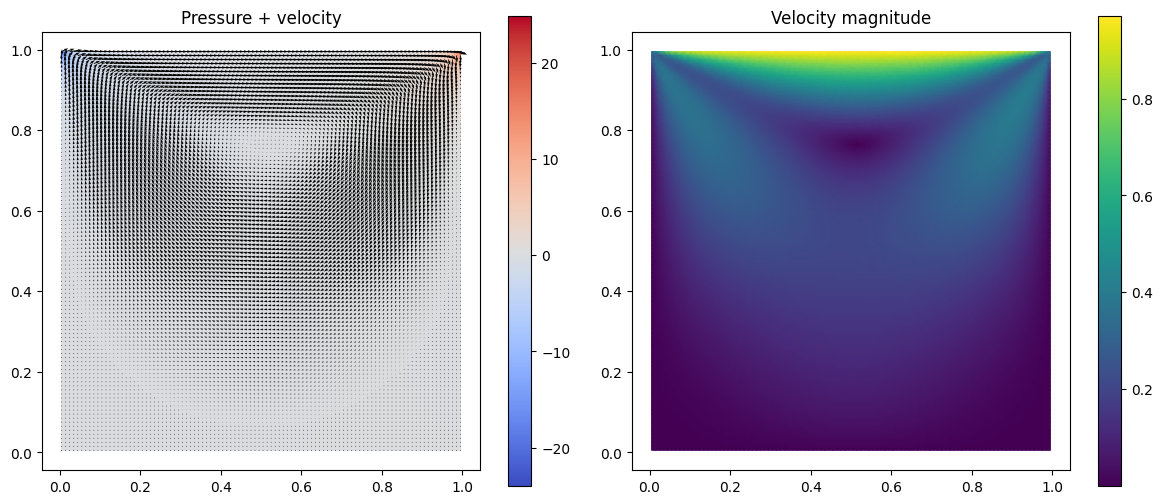

In [66]:
# Cell-centre coordinates for plotting the unstructured fields
xc = np.array([c.center[0] for c in mesh.cells])
yc = np.array([c.center[1] for c in mesh.cells])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Pressure field (filled, interpolated over the cell centres) + velocity vectors
tpc = ax[0].tripcolor(xc, yc, p, shading="gouraud", cmap="coolwarm")
ax[0].quiver(xc, yc, u, v, scale=20, width=0.002)
ax[0].set_title("Pressure + velocity"); ax[0].set_aspect("equal")
fig.colorbar(tpc, ax=ax[0])

# Velocity magnitude
speed = np.sqrt(u**2 + v**2)
spc = ax[1].tripcolor(xc, yc, speed, shading="gouraud", cmap="viridis")
ax[1].set_title("Velocity magnitude"); ax[1].set_aspect("equal")
fig.colorbar(spc, ax=ax[1])

plt.tight_layout()
plt.show()
